# Kurs AWDP - Projekt końcowy 

### Analiza zużycia energii elektrycznej na świecie

ZESPÓŁ: 





- Brzozowski Jakub
- Matuła Teresa
- Moskwa Michał
- Ramota Aleksandra

## 1. Wstęp

Energia jest jednym z kluczowych czynników wpływających na rozwój gospodarczy, funkcjonowanie społeczeństw oraz stan środowiska naturalnego. Analiza zmian w zakresie produkcji i zużycia energii pozwala lepiej zrozumieć przemiany zachodzące w światowym systemie energetycznym, a także ocenić zależności pomiędzy wykorzystaniem poszczególnych źródeł energii a rozwojem gospodarczym regionów i krajów.

Celem niniejszej analizy jest zbadanie zmian w zużyciu energii na świecie na przestrzeni lat oraz określenie zależności pomiędzy zużyciem energii, strukturą wykorzystywanych źródeł energii i wybranymi wskaźnikami gospodarczymi. W ramach analizy dokonano również porównania wybranych państw oraz przedstawiono sytuację Polski na tle innych krajów.

Do przeprowadzenia analizy wykorzystano w projekcie zbiór danych *"World Energy Consumption"*, opublikowany przez użytkownika Pralabh Poudel na platformie Kaggle. Gotowy plik w formacie CSV pobrany ze strony https://www.kaggle.com/datasets/pralabhpoudel/world-energy-consumption/data zawiera dane historyczne dotyczące zużycia energi według krajów i regionów świata.

Plik zawiera dane przygotowane przez organizację Our World in Data (OWID). OWID przetwarza, standaryzuje i łączy dane pochodzące z różnych międzynarodowych źródeł, między innymi z Międzynarodowej Agencji Energetycznej (IEA), Banku Światowego (World Bank), organizacji British Petroleum (BP) oraz Global Carbon Project (GCP), opracowujących raporty i analizy dotyczące sektora energetycznego, gospodarki, wykorzystania zasobów naturalnych oraz emisji gazów cieplarnianych.

Analizowany zbiór danych zawiera informacje o całkowitym zużyciu energii w różnych krajach i regionach świata. Dane obejmują zarówno zużycie energii całkowitej, jak i energii elektrycznej, a także szczegółowe informacje o wykorzystaniu poszczególnych źródeł energii (węgiel, gaz, ropa, źródła odnawialne), emisji CO₂, liczbie ludności oraz wskaźnikach gospodarczych, takich jak produkt krajowy brutto (PKB). 

Tak szeroki zakres danych umożliwia przeprowadzenie zarówno analizy zmian zachodzących w czasie, jak i porównań pomiędzy poszczególnymi państwami.

## 2. Charakterystyka zbioru danych

Do przeprowadzenia analizy wykorzystano język programowania Python. W pierwszym kroku dokonano importu niezbędnych bibliotek, wykorzystywanych do przetwarzania, analizy oraz wizualizacji danych. Następnie wczytano pobrany z platformy Kaggle plik CSV zawierający dane dotyczące światowego zużycia energii.

In [23]:
# ============================================
#                   Importy 
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# ============================================
#               Wczytanie danych 
# ============================================

df = pd.read_csv("World Energy Consumption.csv")

Po wczytaniu zestawu danych przygotowano kod, który pozwolił odpowiedzieć na pytania o wielkość zbioru (liczba rekordów, liczba zmiennych), zakres lat, występujące kraje i regiony oraz typy danych.

In [24]:
# ============================================
#        Podstawowe informacje o zbiorze
# ============================================

# Ogólne informacje o zbiorze
df.info()


# Rozmiar zbioru
print("\nWielkość zbioru:")
print("Liczba rekordów:", df.shape[0])
print("Liczba kolumn:", df.shape[1])

# Zakres lat
print("\nZakres lat:")
print(df["year"].min(), "-", df["year"].max())

# Liczba krajów/regionów
print("Liczba krajów/regionów:", df["country"].nunique())

# Typy danych
print("\nTypy danych:")
#print(df.dtypes)
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), str(2)
memory usage: 21.9 MB

Wielkość zbioru:
Liczba rekordów: 22012
Liczba kolumn: 129

Zakres lat:
1900 - 2022
Liczba krajów/regionów: 306

Typy danych:


country                       str
year                        int64
iso_code                      str
population                float64
gdp                       float64
                           ...   
wind_elec_per_capita      float64
wind_electricity          float64
wind_energy_per_capita    float64
wind_share_elec           float64
wind_share_energy         float64
Length: 129, dtype: object

W kolejnym kroku dokonano bardziej szczegółowego przeglądu danych, m.in. pod kątem występowania braków informacji, czy też duplikatów.

In [25]:
# ============================================
#        Podgląd danych
# ============================================

# początkowe rekordy ze zbioru

df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [26]:
# końcowe rekordy ze zbioru

df.tail()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
22007,Zimbabwe,2018,ZWE,15052191.0,2.271535e+10,NaN,NaN,NaN,NaN,25.910,...,0.218,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22008,Zimbabwe,2019,ZWE,15354606.0,NaN,NaN,NaN,NaN,NaN,24.748,...,0.364,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22009,Zimbabwe,2020,ZWE,15669663.0,NaN,NaN,NaN,NaN,NaN,22.336,...,0.395,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22010,Zimbabwe,2021,ZWE,15993525.0,NaN,NaN,NaN,NaN,NaN,23.760,...,0.498,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22011,Zimbabwe,2022,ZWE,16320539.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# ========================================================
#         Sprawdzenie duplikatów i braków w danych
# ========================================================

# występowanie duplikatów w zbiorze danych
print("Duplikaty:", df.duplicated().sum())

Duplikaty: 0


In [28]:
# Liczba brakujących wartości w poszczególnych kolumnach
# zliczenie wystąpień brakujących wartości (NaN/null/missing value) w każdej kolumnie 
# i zestawienie ich począwszy od tej, która ma tych braków najwięcej
df.isna().sum().sort_values(ascending=False) 

biofuel_cons_change_pct    20265
solar_cons_change_pct      19888
biofuel_cons_per_capita    19710
wind_cons_change_pct       19599
nuclear_cons_change_pct    19545
                           ...  
oil_prod_change_twh         4864
oil_production              4607
population                  3889
country                        0
year                           0
Length: 129, dtype: int64

In [29]:
# łączna liczba braków danych w poszczególnych latach

missing_by_year = df.groupby('year').apply(lambda x: x.isna().sum().sum())
missing_by_year

year
1900    14224
1901    13871
1902    13869
1903    13868
1904    13866
        ...  
2018    17382
2019    17700
2020    17586
2021    17465
2022     6658
Length: 123, dtype: int64

#### Wnioski:

Wczytany zbiór danych składa się z 22 012 rekordów oraz 129 zmiennych. Dane obejmują okres od 1900 do 2022 roku, dzięki czemu możliwe jest przeanalizowanie długookresowych zmian zachodzących w światowym systemie energetycznym. Zbiór zawiera informacje dotyczące 306 krajów i regionów, przy czym oprócz pojedynczych państw uwzględniono również wybrane regiony oraz agregaty geograficzne.

W zbiorze występują braki danych, których liczba różni się w zależności od zmiennej oraz okresu. Jest to związane między innymi z różną dostępnością danych historycznych dla poszczególnych krajów i wskaźników. Większa liczba brakujących wartości występuje w starszych (początkowych) latach badanego okresu. Wraz z upływem czasu kompletność danych ulega poprawie.

## 3. Kompletność zbioru danych

W zbiorze nie stwierdzono zduplikowanych rekordów. Natomiast ze względu na występowanie brakujących wartości przed przystąpieniem do właściwej analizy konieczne jest określenie ich zakresu oraz ocena wpływu na dalsze obliczenia. 

W tym celu przeprowadzono analizę kompletności zbioru, wykorzystując zarówno zestawienia liczbowe, jak i wizualizacje umożliwiające określenie skali występowania braków oraz ich rozkładu w czasie, pomiędzy poszczególnymi krajami i zmiennymi.

Pierwszym etapem analizy było określenie kompletności poszczególnych zmiennych.

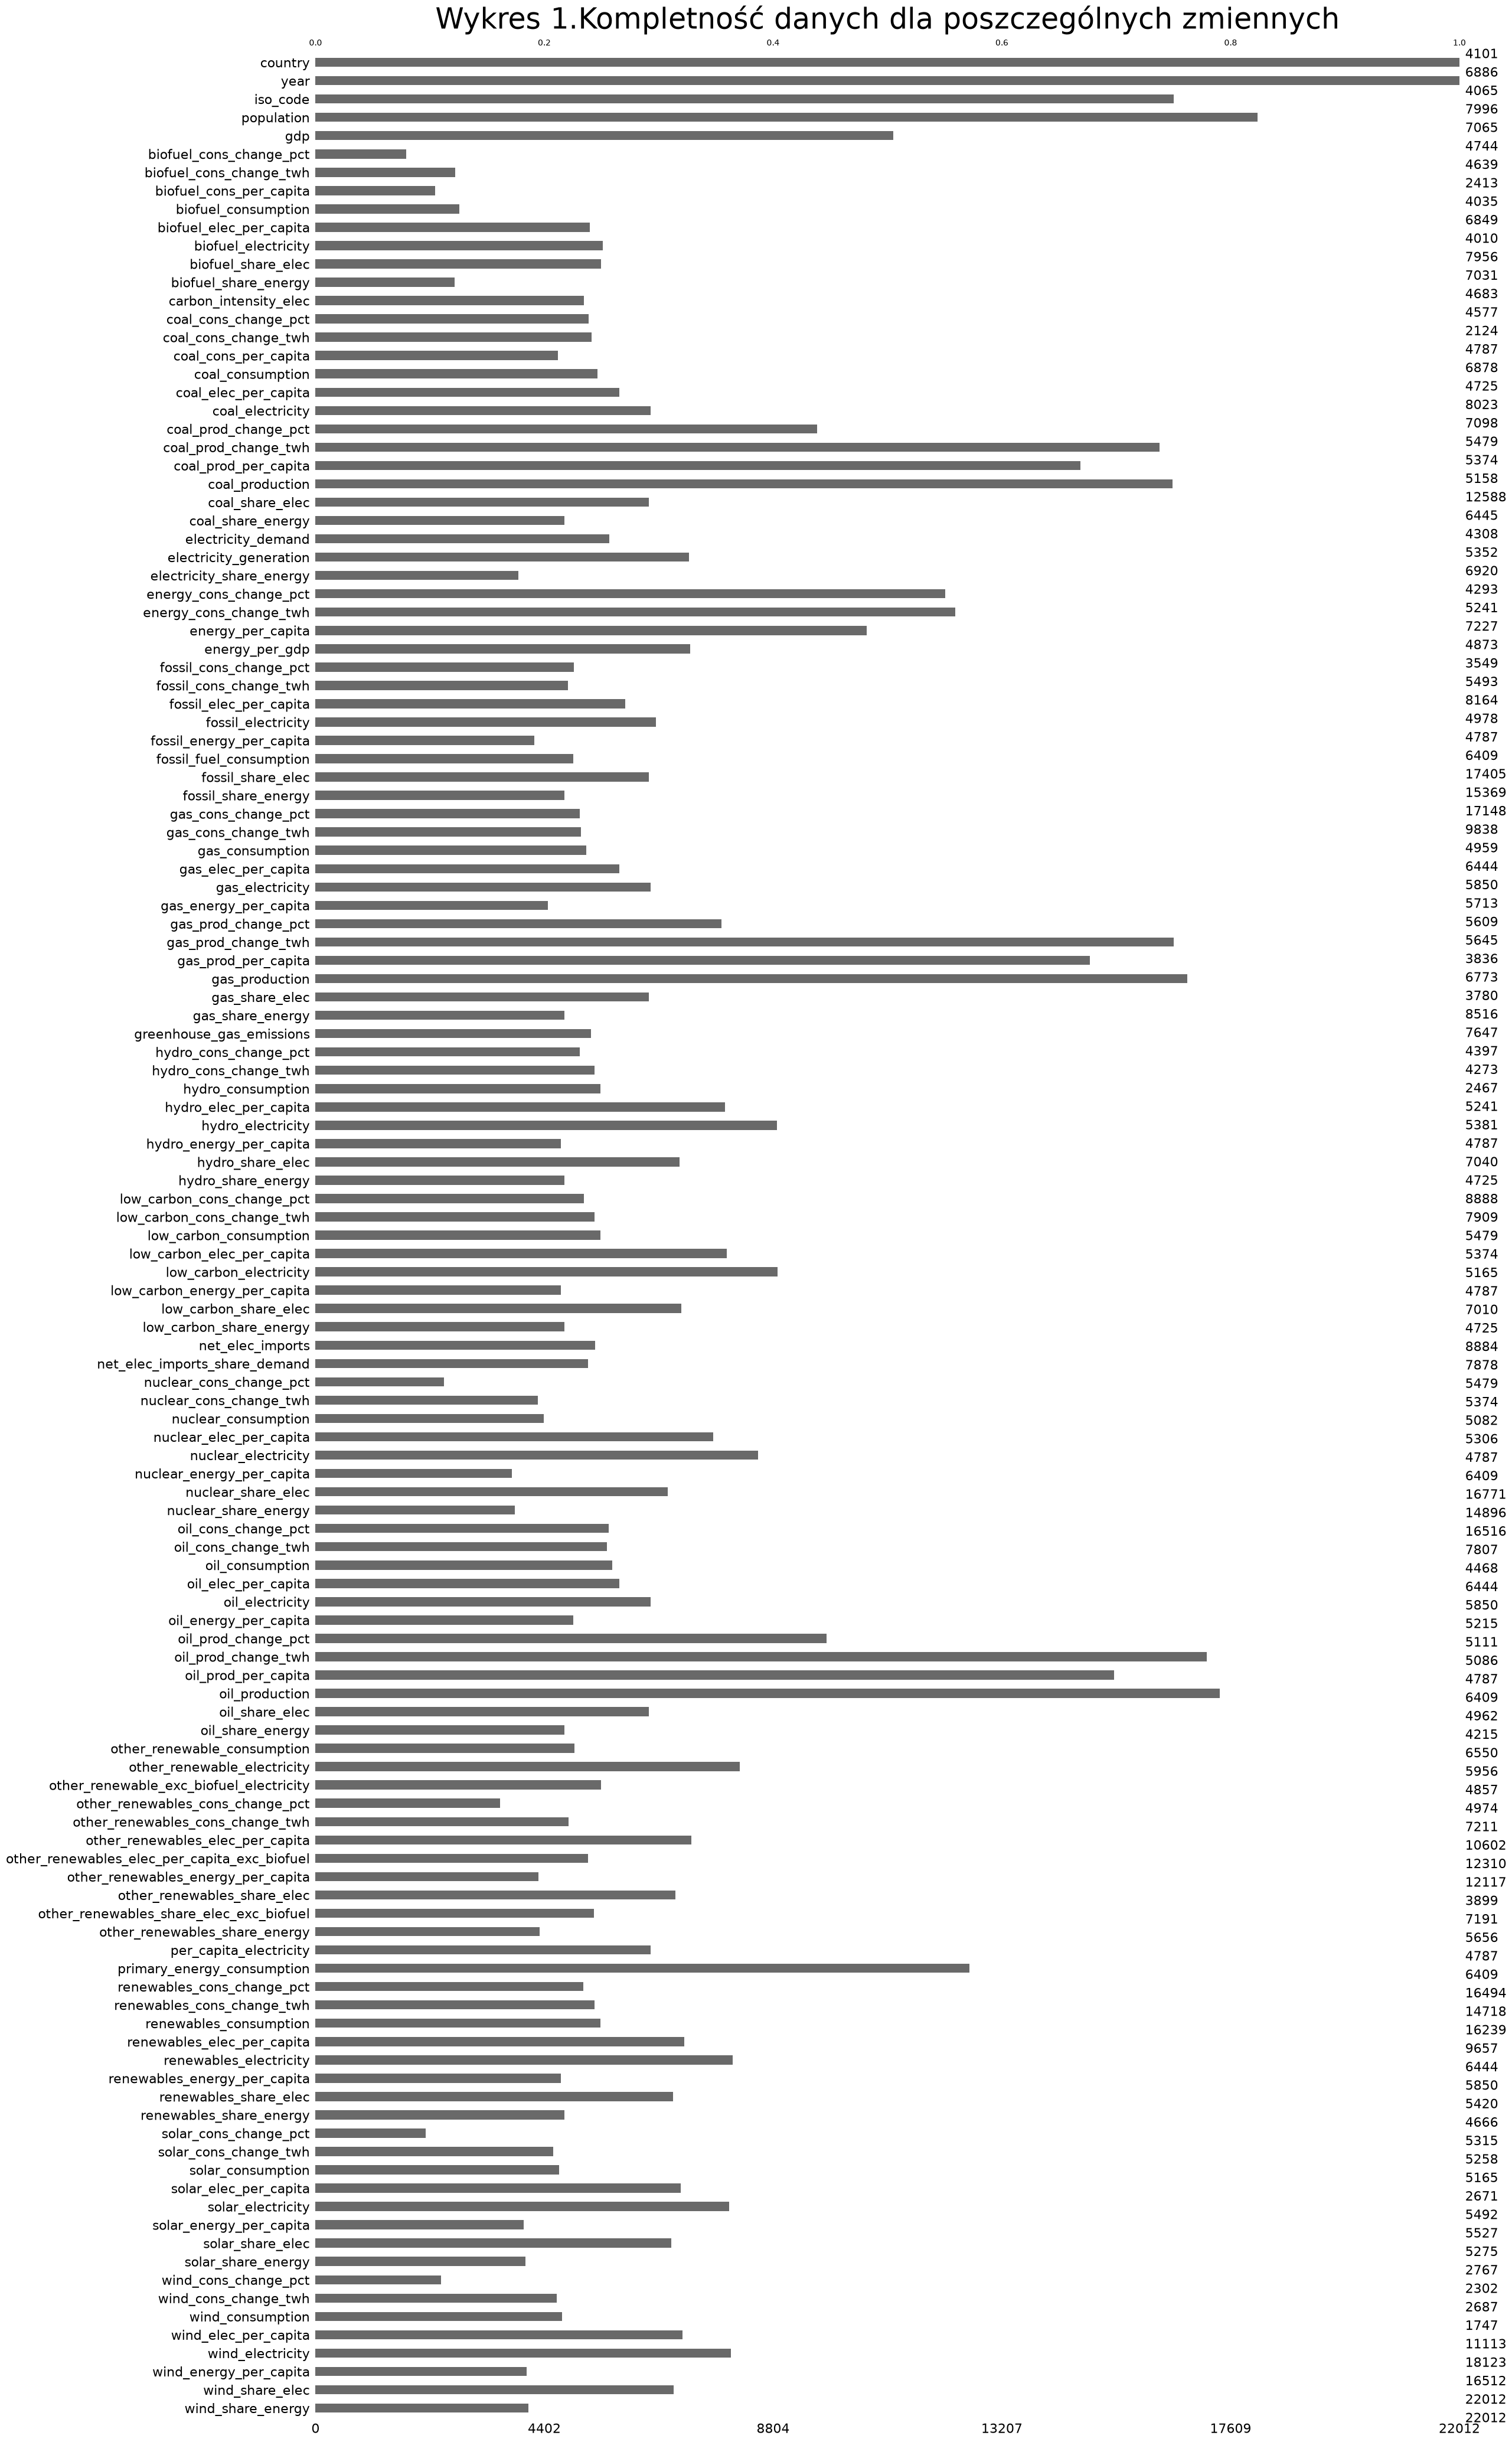

In [30]:
# ========================================================
#         Wizualizacja braków danych
# ========================================================

# Wykres 1: kompletność danych dla poszczególnych zmiennych

msno.bar(df)

plt.title(
    'Wykres 1.Kompletność danych dla poszczególnych zmiennych',
    fontsize=35,
    pad=30
)
plt.gca().invert_yaxis()
plt.show()

Wykres 1 przedstawia poziom kompletności danych dla poszczególnych zmiennych. Widoczne są różnice w liczbie dostępnych obserwacji pomiędzy zmiennymi. Zmienne o słupkach sięgających pełnej długości charakteryzują się kompletnymi lub niemal kompletnymi danymi, natomiast krótsze słupki wskazują na większy udział brakujących wartości.

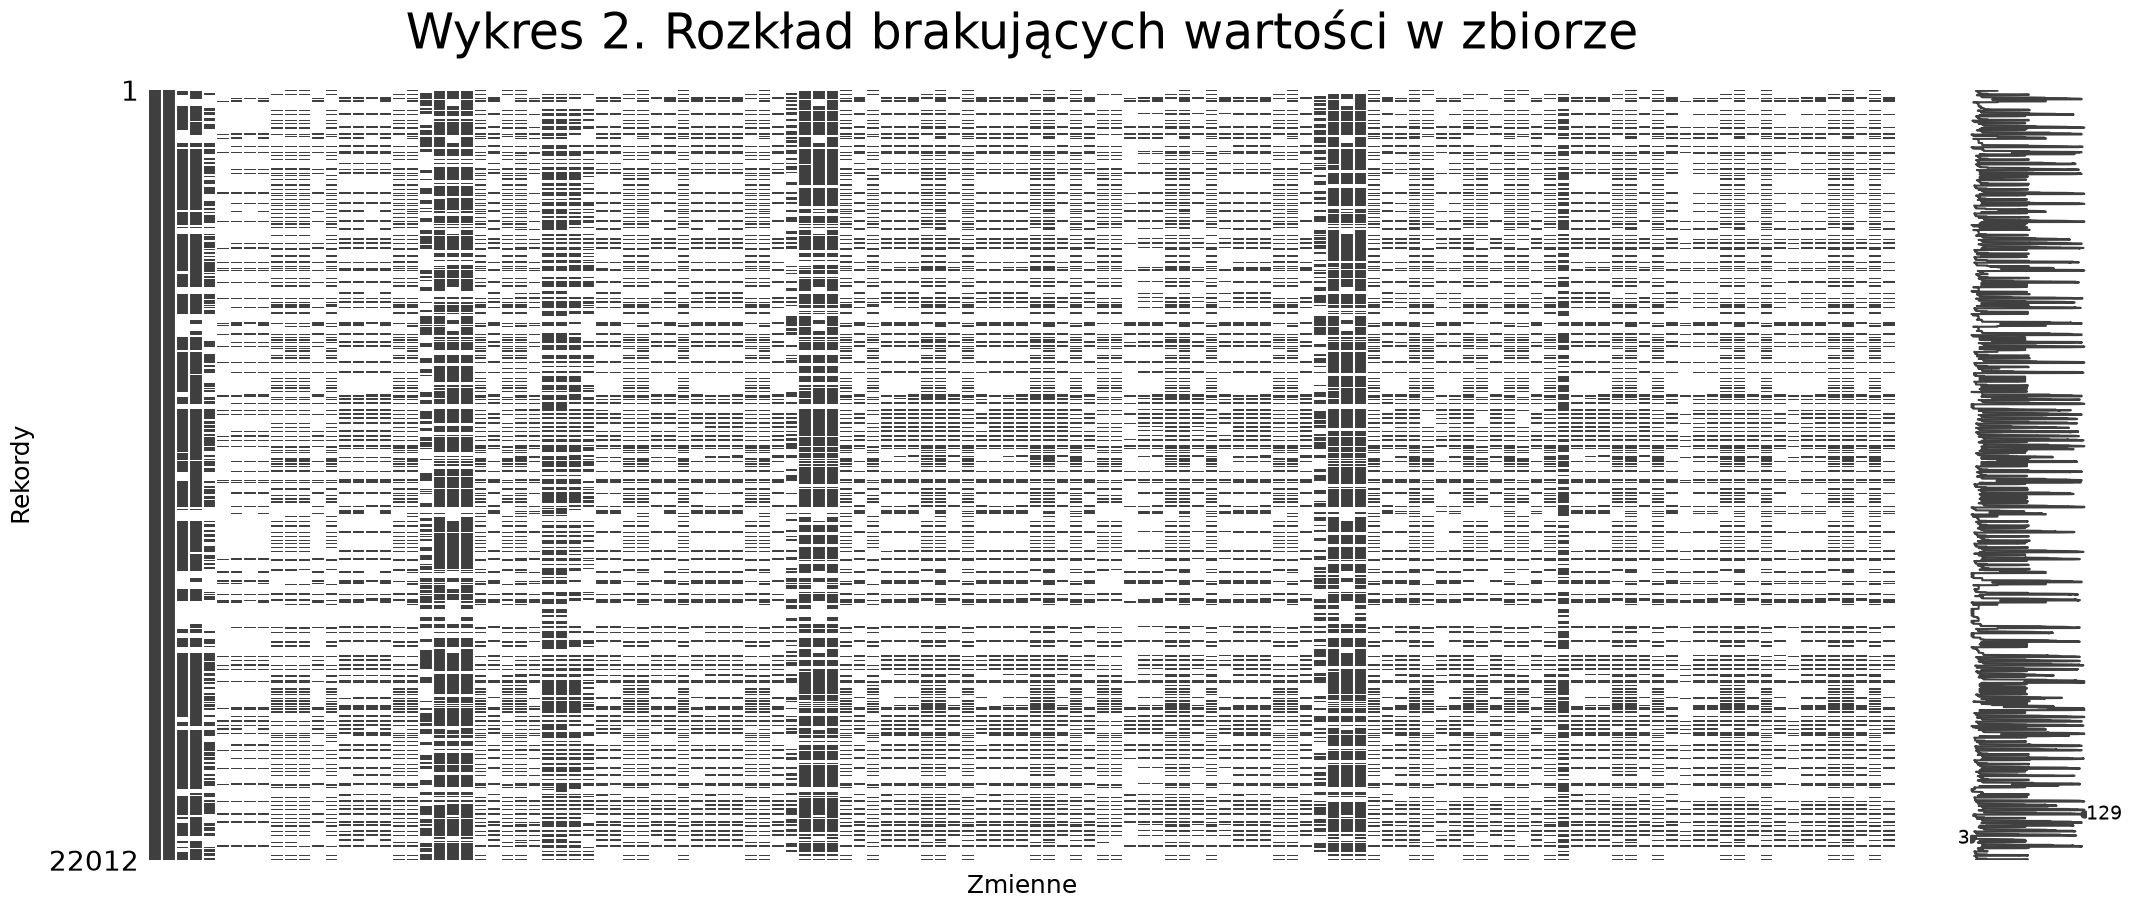

In [31]:
# Wykres 2: poglądowy wykres rozkładu brakujących wartości w zbiorze

msno.matrix(df)
plt.title(
    'Wykres 2. Rozkład brakujących wartości w zbiorze',
    fontsize=35,
    pad=30
)

plt.xlabel('Zmienne', fontsize=18, labelpad=10)
plt.ylabel('Rekordy', fontsize=18, labelpad=10)

plt.show()

Macierz braków zaprezentowana na Wykresie 2 przedstawia rozmieszczenie brakujących wartości w poszczególnych rekordach i zmiennych. Jasne pola oznaczają brakujące wartości, natomiast ciemne pola wskazują na wartości dostępne. Położenie poszczególnych pól umożliwia określenie, których rekordów oraz zmiennych dotyczą występujące braki.

Do Wykresu 2 można dodać informacje szczegółowe o numerze rekordu i nazwie zmiennej.

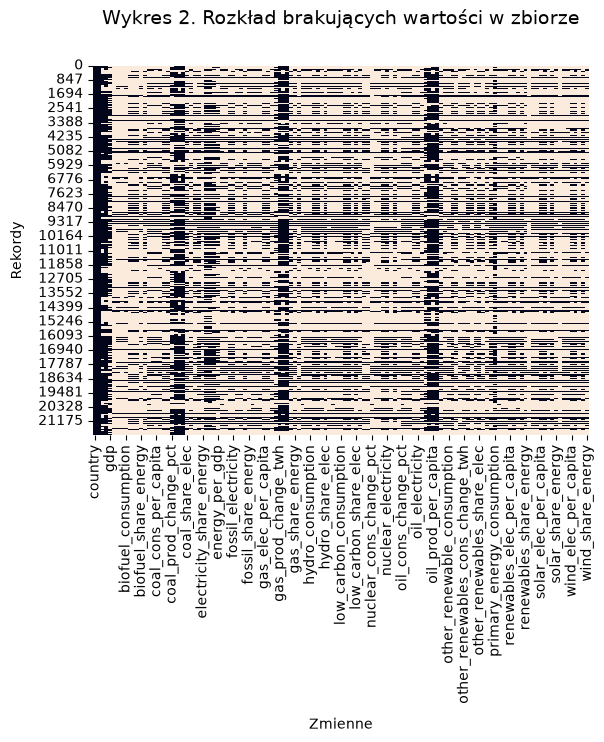

In [32]:
sns.heatmap(df.isna(), cbar=False)  

plt.title(
    'Wykres 2. Rozkład brakujących wartości w zbiorze',
    fontsize=14,
    pad=30
)

plt.xlabel('Zmienne', fontsize=10, labelpad=10)
plt.ylabel('Rekordy', fontsize=10, labelpad=10)

plt.show()

W kolejnym kroku przeanalizowano zróżnicowanie udziału brakujących wartości w poszczególnych zmiennych na przestrzeni badanego okresu.

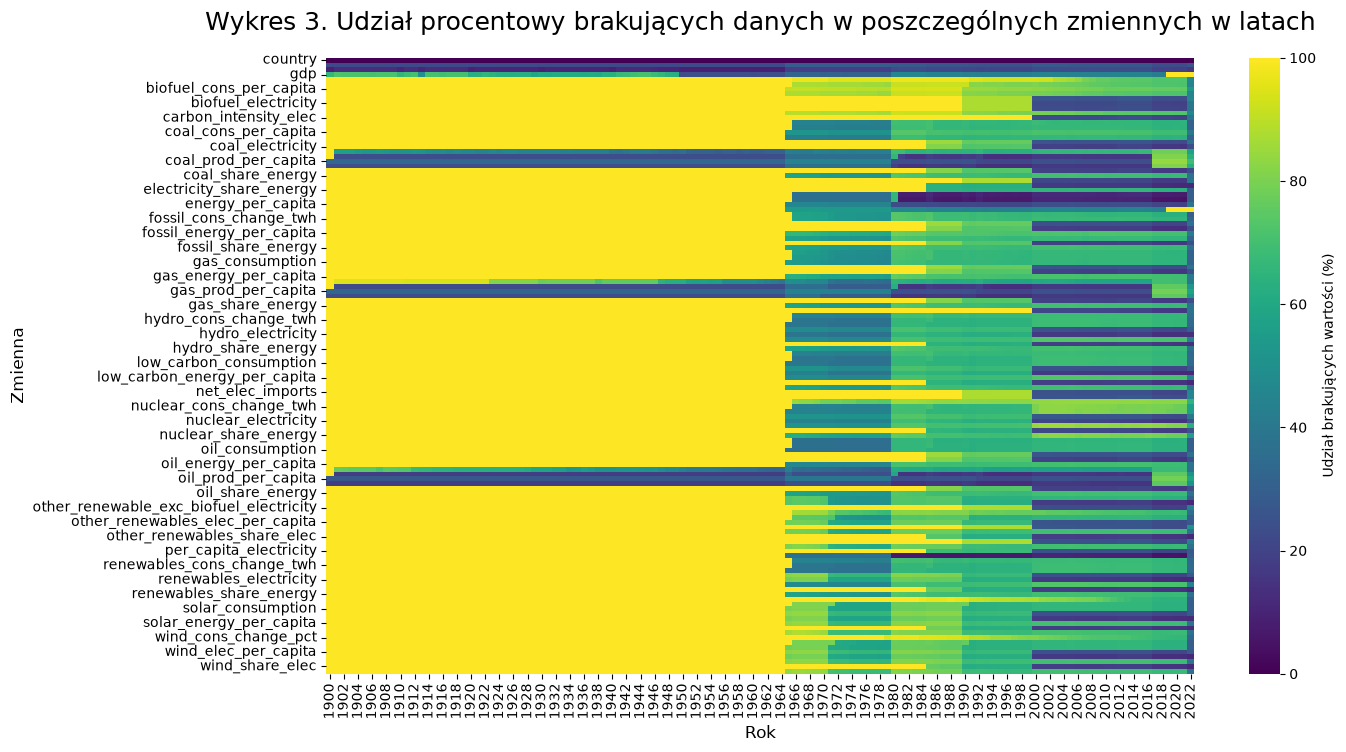

In [33]:
# Wykres 3. Udział brakujących danych w poszczególnych zmiennych w latach

missing_by_year_var = df.groupby('year').apply(
    lambda x: x.isna().mean() * 100
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    missing_by_year_var.T,
    cmap='viridis',
    cbar_kws={'label': 'Udział brakujących wartości (%)'}
)

plt.title(
    'Wykres 3. Udział procentowy brakujących danych w poszczególnych zmiennych w latach',
    fontsize=18,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Zmienna', fontsize=12)

plt.show()


Na wykresie 3 wyraźnie widoczna jest większa koncentracja brakujących wartości w starszych latach, podczas gdy dla nowszych okresów dane są na ogół bardziej kompletne. Jednocześnie poszczególne zmienne charakteryzują się zróżnicowanym poziomem dostępności danych.

W celu dokładniejszego określenia rozkładu brakujących wartości przeanalizowano dostępność danych dla wybranych zmiennych, istotnych z punktu widzenia dalszych etapów analizy. Szczególną uwagę poświęcono zmiennym dotyczącym produktu krajowego brutto, liczby ludności oraz zużycia energii pierwotnej.

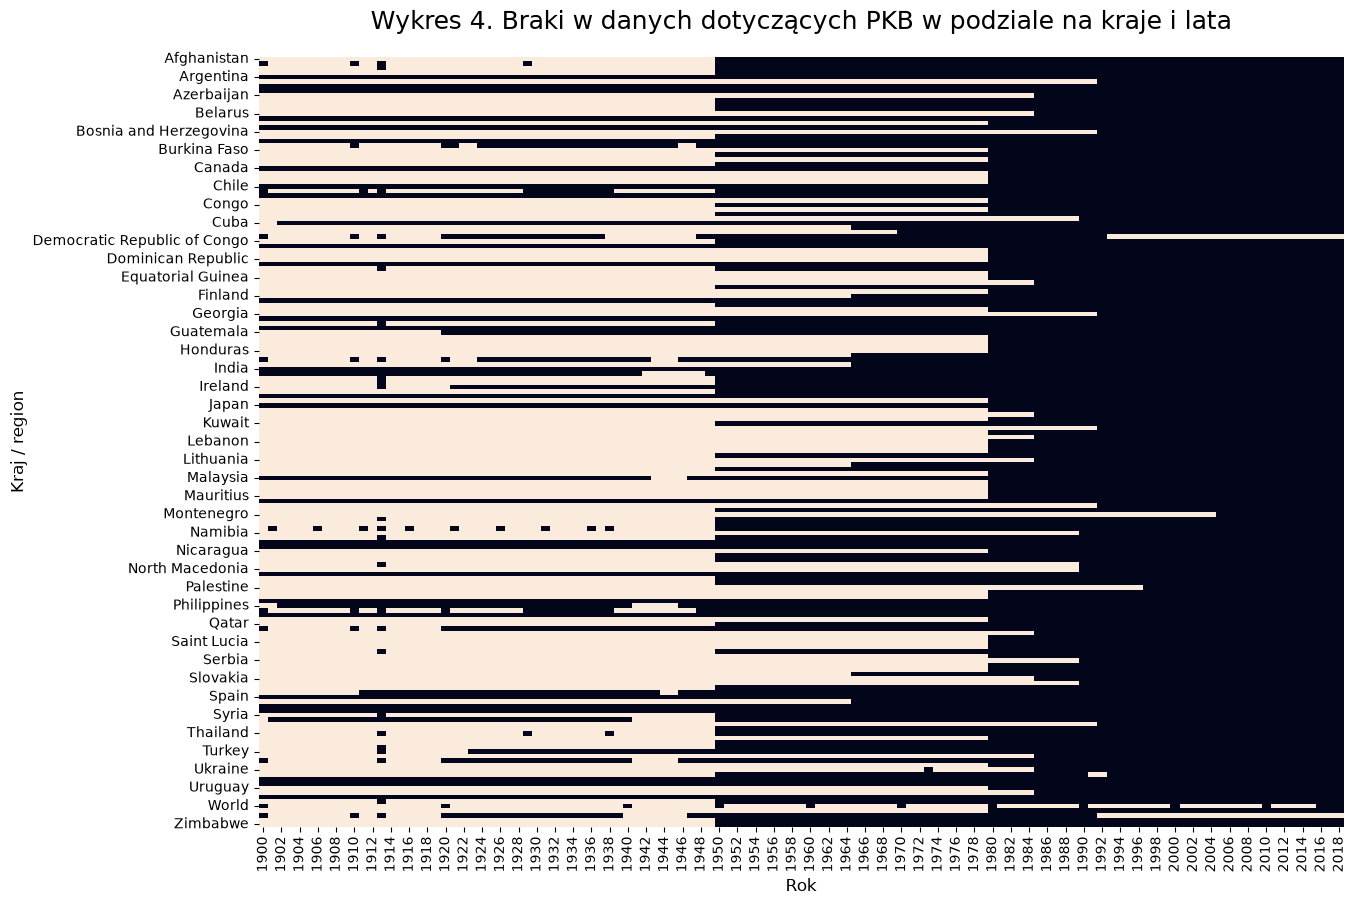

In [34]:
# Wykres 4: Macierz brakujących danych dotyczących PKB w podziale na kraje i lata

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.pivot_table(
        index='country',
        columns='year',
        values='gdp'
    ).isna(),
    cbar=False
)

plt.title(
    'Wykres 4. Braki w danych dotyczących PKB w podziale na kraje i lata',
    fontsize=18,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Kraj / region', fontsize=12)

plt.show()

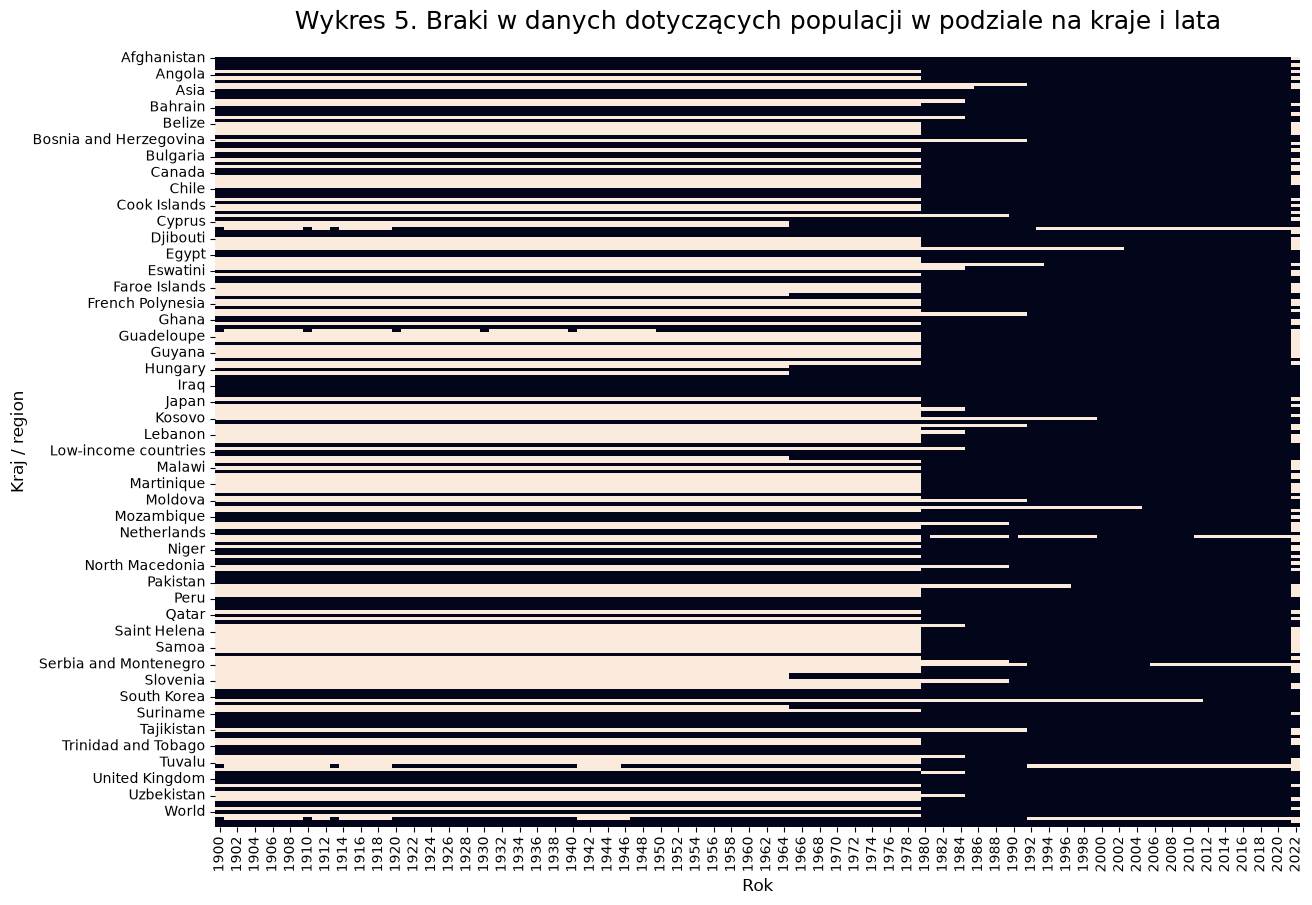

In [35]:
# Wykres 5: Macierz brakujących danych dotyczących populacji w podziale na kraje i lata

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.pivot_table(
        index='country',
        columns='year',
        values='population'
    ).isna(),
    cbar=False
)

plt.title(
    'Wykres 5. Braki w danych dotyczących populacji w podziale na kraje i lata',
    fontsize=18,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Kraj / region', fontsize=12)

plt.show()


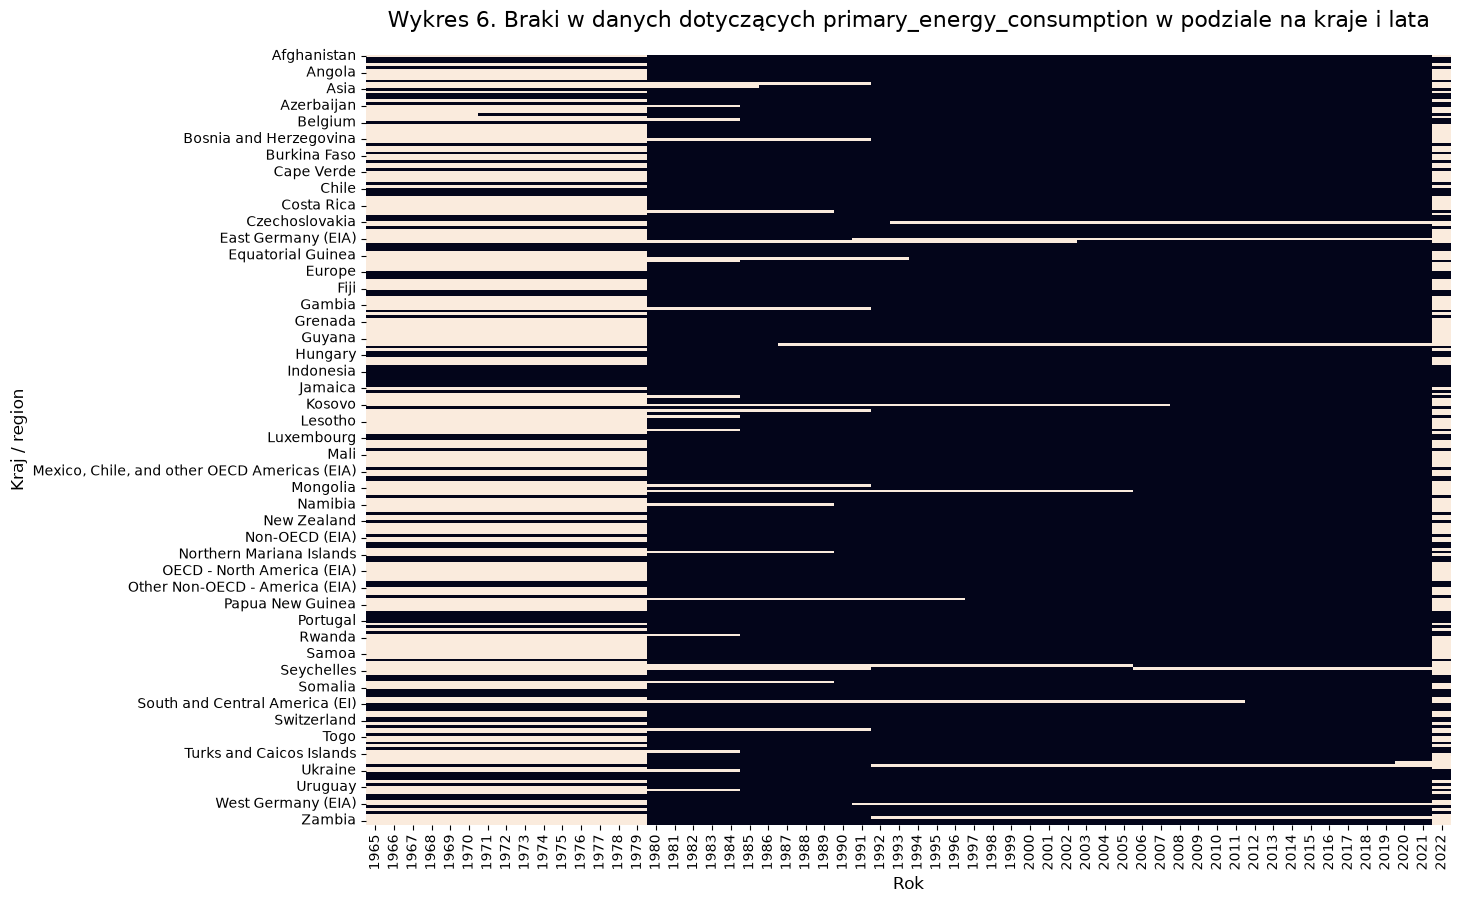

In [36]:
# Wykres 6: Macierz brakujących danych dotyczących zmiennej primary_energy_consumption w podziale na kraje i lata

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.pivot_table(
        index='country',
        columns='year',
        values='primary_energy_consumption'
    ).isna(),
    cbar=False
)

plt.title(
    'Wykres 6. Braki w danych dotyczących primary_energy_consumption w podziale na kraje i lata',
    fontsize=16,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Kraj / region', fontsize=12)

plt.show()

#### Wnioski:

Przeprowadzona analiza kompletności zbioru danych wykazała, że poziom dostępności informacji jest zróżnicowany w zależności od zmiennej, kraju oraz roku. W zbiorze występują braki danych, przy czym ich większa koncentracja widoczna jest w starszych latach badanego okresu. W nowszych latach dane są na ogół bardziej kompletne, co może wynikać z większej dostępności i systematyczności prowadzonych pomiarów oraz statystyk dotyczących energii, gospodarki i demografii.

Analiza poszczególnych zmiennych wykazała również, że stopień kompletności danych nie jest jednakowy. Różnice te są widoczne między innymi dla produktu krajowego brutto (gdp), liczby ludności (population) oraz zużycia energii pierwotnej (primary_energy_consumption). Dostępność danych różni się także pomiędzy poszczególnymi krajami i regionami, co należy uwzględnić podczas przeprowadzania dalszych analiz porównawczych.

Jednocześnie w analizowanym zbiorze nie stwierdzono zduplikowanych rekordów. Oznacza to, że przed rozpoczęciem właściwej analizy nie ma potrzeby przeprowadzania procesu usuwania duplikatów. Konieczne jest natomiast odpowiednie postępowanie z brakującymi wartościami.

W związku z powyższym w kolejnym etapie przeprowadzone zostanie przygotowanie i oczyszczenie danych. Obejmie ono przede wszystkim wybór danych istotnych z punktu widzenia prowadzonych analiz oraz określenie sposobu obsługi braków w danych, tak aby ograniczyć ich wpływ na wyniki końcowe.

## 4.  Przygotowanie i oczyszczenie danych

Dane OWID są wynikiem połączenia danych pochodzących z wielu źródeł (IEA, BP, GCP, World Bank), co powoduje występowanie różnic w dostępności danych dla poszczególnych krajów oraz lat. W przypadku niektórych zmiennych występują luki w danych wynikające z braku raportowania w latach historycznych. W związku z tym, przed przystąpieniem do właściwej analizy zużycia energii na świecie konieczne było przygotowanie i oczyszczenie pobranego zbioru danych.

Celem tego etapu było uzyskanie zbioru odpowiedniego do przeprowadzenia dalszych analiz, tak aby zapewnić ich spójność, kompletność oraz możliwość przeprowadzenia rzetelnych porównań. 

Proces przygotowania danych obejmował kilka etapów: selekcję obserwacji, obsługę braków danych, ograniczenie zakresu lat oraz przygotowanie zbioru do dalszych analiz eksploracyjnych i wizualizacji. Działania podjęte na tym etapie wynikały z charakterystyki zbioru oraz problemów zidentyfikowanych podczas wcześniejszego przeglądu jego kompletności.

Z racji tego, że w ramach projektu przedmiotem analiz są porównania między krajami, w pierwszej kolejności zweryfikowano wartości zmiennej "country", aby sprawdzić, jakie kraje znajdują się w zbiorze. 

In [37]:
# =================================================================================
#         Sprawdzenie liczby jednostek posiadających i nieposiadających kod ISO
# =================================================================================

print("Liczba wszystkich jednostek:", df['country'].nunique())

print("Liczba jednostek bez kodu ISO:", df.loc[df['iso_code'].isna(), 'country'].nunique())

Liczba wszystkich jednostek: 306
Liczba jednostek bez kodu ISO: 87


In [38]:
# wyświetlenie jednostek bez przypisanego kodu ISO

df.loc[df['iso_code'].isna(),'country'].drop_duplicates().sort_values().tolist()

['ASEAN (Ember)',
 'Africa',
 'Africa (EI)',
 'Africa (Ember)',
 'Africa (Shift)',
 'Asia',
 'Asia & Oceania (EIA)',
 'Asia (Ember)',
 'Asia Pacific (EI)',
 'Asia and Oceania (Shift)',
 'Australia and New Zealand (EIA)',
 'CIS (EI)',
 'Central & South America (EIA)',
 'Central America (EI)',
 'Central and South America (Shift)',
 'Czechoslovakia',
 'EU28 (Shift)',
 'East Germany (EIA)',
 'Eastern Africa (EI)',
 'Eurasia (EIA)',
 'Eurasia (Shift)',
 'Europe',
 'Europe (EI)',
 'Europe (Ember)',
 'Europe (Shift)',
 'European Union (27)',
 'European Union (EIA)',
 'G20 (Ember)',
 'G7 (Ember)',
 'Hawaiian Trade Zone (EIA)',
 'High-income countries',
 'IEO - Africa (EIA)',
 'IEO - Middle East (EIA)',
 'IEO OECD - Europe (EIA)',
 'Kosovo',
 'Latin America and Caribbean (Ember)',
 'Low-income countries',
 'Lower-middle-income countries',
 'Mexico, Chile, and other OECD Americas (EIA)',
 'Middle Africa (EI)',
 'Middle East (EI)',
 'Middle East (EIA)',
 'Middle East (Ember)',
 'Middle East (Shif

W zbiorze OWID oprócz państw znajdują się również agregaty geograficzne, takie jak World, Europe, Asia, czy ASEAN (Ember), OPEC. Jednostki te odnoszą się m.in. do kontynentów, regionów oraz grupy państw, czy innych organizacji. Nie są one porównywalne z pojedynczymi krajami, a ich obecność w rozpatrywanym zbiorze zaburzałaby analizy trendów, wielkości i porównań. 

W związku z tym do dalszego przetwarzania pozostawiono wyłącznie obserwacje, dla których dostępny jest kod kraju (iso_code). Usunięcie jednostek bez kodu ISO pozwoliło skutecznie pominąć pozycje będące agregatami.
W efekcie utworzono odrębny zbiór df_2, który będzie wykorzystywany w dalszych analizach realizowanych na poziomie krajów.

In [79]:
# ==============================================================================
#         Pominięcie danych niebędących przedmiotem analizy w ujęciu krajów
# ==============================================================================

# utworzenie zbioru zawierającego wyłącznie jednostki z kodem ISO, będące przedmiotem analizy (kraje, nie regiony)
df_2 = df[df['iso_code'].notna()].copy()

# wyświetlenie liczby krajów w zbiorze danych po odfiltrowaniu jednostek niebędących przedmiotem analizy (regiony, itp.)
print("Liczba krajów:", df_2['country'].nunique())

# sprawdzenie, czy dane zostały poprawnie przefiltrowane (zestawienie poglądowe)
df_2.country.unique().tolist()

Liczba krajów: 219


['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Angola',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Falkland Islands',
 'Faroe Islands',
 'Fiji',
 'Finland',
 'France',
 'F

Ze względu na występowanie wartości brakujących w zbiorze danych w kolejnym kroku dokonano wyliczenia udziału procentowego braków w danych historycznych dla każdego okresu dostępnego w źródle.

In [80]:
# udział brakujących danych dla lat dostępnych w zbiorze

missing_pct_year = df_2.groupby('year').apply(lambda x: x.isna().mean().mean() * 100)
missing_pct_year = missing_pct_year.round(2).astype(str) + '%'
missing_pct_year

year
1900    93.95%
1901    91.93%
1902    91.92%
1903    91.91%
1904    91.89%
         ...  
2018    41.98%
2019    43.11%
2020    43.15%
2021    43.14%
2022    32.13%
Length: 123, dtype: str

W zbiorze występują lata, które mają ponad 60–94% braków w zmiennych. Okresy ze zmiennymi o tak niskiej dostępności danych:

* nie nadają się do analizy trendów,
* utrudniają wizualizacje,
* mogą prowadzić do błędnych interpretacji.

Na potrzeby oceny, jak skrócenie szeregu czasowego wpłynie na kompletność danych, przeanalizowano poziom braków dla pięciu wybranych przedziałów czasowych.

In [81]:
# obliczenie procentu brakujących wartości w analizowanych przedziałach czasowych

periods = {
    "1900–2022": (1900, 2022), # pełny szereg czasowy dostępny w zbiorze
    "1950–2022": (1950, 2022),
    "1980–2022": (1980, 2022),
    "1990–2022": (1990, 2022),
    "2000–2022": (2000, 2022)
}

results = []

for name, (start, end) in periods.items():
    temp = df_2[(df_2["year"] >= start) & (df_2["year"] <= end)]
    
    results.append({
        "okres": name,
        "liczba_obserwacji": len(temp),
        "procent_braków": temp.isna().mean().mean() * 100
    })

comparison = pd.DataFrame(results)
print(comparison)

       okres  liczba_obserwacji  procent_braków
0  1900–2022              16512       65.874149
1  1950–2022              11912       56.181572
2  1980–2022               9017       49.556608
3  1990–2022               7043       44.188248
4  2000–2022               4906       37.368260


Powyższe zestawienie wskazuje, że wraz ze skracaniem szeregu czasowego poprzez pominięcie najstarszych obserwacji zmniejsza się udział brakujących danych. Oznacza to, że początkowe lata analizowanego szeregu charakteryzują się większą liczbą braków, co może negatywnie wpływać na jakość analiz prowadzonych dla pełnego okresu 1900–2022. Jednocześnie ograniczenie zakresu czasowego prowadzi do zmniejszenia liczby dostępnych obserwacji.

Aby zwiększyć jakość analizy, ograniczono zakres lat do przedziału 2000–2022, co pozwala skupić się na okresie dynamicznych zmian w sektorze energetycznym oraz uniknąć problemów związanych z niekompletnością danych historycznych.  W rezultacie otrzymano bardziej kompletny i porównywalny zbiór danych, odpowiedni do przeprowadzenia dalszej analizy eksploracyjnej.

In [82]:
# ========================================================================
#         Pominięcie rekordów z lat historycznych
# ========================================================================

# wyfiltrowanie danych dla okresów po roku 1999
df_2 = df_2[df_2['year'] >= 2000]

# sprawdzenie minimalnej wartości w kolumnie 'year' po usunięciu rekordów z lat historycznych
print("Minimalny rok w zbiorze danych po filtrowaniu:", df_2['year'].min())

# podgląd danych po usunięciu rekordów z lat historycznych
df_2.head()

Minimalny rok w zbiorze danych po filtrowaniu: 2000


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
123,Afghanistan,2000,AFG,19542986.0,1.128379e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
124,Afghanistan,2001,AFG,19688634.0,1.102127e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
125,Afghanistan,2002,AFG,21000258.0,1.880487e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
126,Afghanistan,2003,AFG,22645136.0,2.107434e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
127,Afghanistan,2004,AFG,23553554.0,2.233257e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN


Dalej przeanalizowano zmienne znajdujące się w nowo utworzonym zbiorze danych pod kątem występowania brakujących wartości.

In [83]:
# ========================================================================
#         Analiza braków danych dla zmiennych w zbiorze 
# ========================================================================

# obliczenie udziału brakujących wartości w każdej zmiennej
missing_pct = df_2.isna().mean()

# wyświetlenie udziału brakujących wartości w każdej zmiennej
print("Udział brakujących wartości w każdej zmiennej:")
print(missing_pct.round(4).sort_values(ascending=False))

Udział brakujących wartości w każdej zmiennej:
nuclear_cons_change_pct       0.8589
nuclear_cons_change_twh       0.8239
nuclear_share_energy          0.8221
nuclear_consumption           0.8200
nuclear_energy_per_capita     0.8200
                               ...  
primary_energy_consumption    0.0118
population                    0.0067
country                       0.0000
year                          0.0000
iso_code                      0.0000
Length: 129, dtype: float64


Przyjęto próg 60% braków, powyżej którego zmienną należałoby usunąć ze zbioru do dalszej analizy.

In [84]:
# ========================================================================
#         Pominięcie zmiennych z nadmierną liczbą braków danych (>60%)
# ========================================================================

# ustalenie progu braków danych, powyżej którego zmienne zostaną pominięte w dalszej analizie
threshold = 0.60

# identyfikacja zmiennych, które przekraczają przyjęty próg
removed_cols = missing_pct[missing_pct > threshold]

print("\nZmienne do usunięcia:")

if removed_cols.empty:
    print("Brak zmiennych przekraczających ustalony próg braków.")
else:
    print((removed_cols * 100).round(2))
    df_3 = df_2.drop(columns=removed_cols.index)


Zmienne do usunięcia:
biofuel_cons_change_pct    80.04
biofuel_cons_change_twh    75.56
biofuel_cons_per_capita    75.13
biofuel_consumption        75.13
biofuel_share_energy       75.85
                           ...  
wind_cons_change_pct       72.10
wind_cons_change_twh       62.96
wind_consumption           62.96
wind_energy_per_capita     62.96
wind_share_energy          68.39
Length: 63, dtype: float64


In [85]:
#zliczenie liczby usuniętych zmiennych 
print("Liczba usuniętych zmiennych: ", removed_cols.count())

Liczba usuniętych zmiennych:  63


In [86]:
# wyświetlenie listy zmiennych pozostałych w zbiorze danych po usunięciu zmiennych z nadmierną liczbą braków danych
print("Zmienne pozostałe w zbiorze danych:")
df_3.columns.tolist()

Zmienne pozostałe w zbiorze danych:


['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'biofuel_elec_per_capita',
 'biofuel_electricity',
 'biofuel_share_elec',
 'carbon_intensity_elec',
 'coal_elec_per_capita',
 'coal_electricity',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'coal_share_elec',
 'electricity_demand',
 'electricity_generation',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'energy_per_capita',
 'energy_per_gdp',
 'fossil_elec_per_capita',
 'fossil_electricity',
 'fossil_share_elec',
 'gas_elec_per_capita',
 'gas_electricity',
 'gas_prod_change_twh',
 'gas_prod_per_capita',
 'gas_production',
 'gas_share_elec',
 'greenhouse_gas_emissions',
 'hydro_elec_per_capita',
 'hydro_electricity',
 'hydro_share_elec',
 'low_carbon_elec_per_capita',
 'low_carbon_electricity',
 'low_carbon_share_elec',
 'net_elec_imports',
 'net_elec_imports_share_demand',
 'nuclear_elec_per_capita',
 'nuclear_electricity',
 'nuclear_share_elec',
 'oil_elec_per_capita',
 'oil_electricity',
 'o

Na podstawie wyników zwróconych w poprzednim kroku, z pierwotnego zbioru danych usunięte zostały 63 zmienne, które w analizowanym okresie 2000-2022 miały braki w danych przekroczające zakładany próg 60%. 

Po usunięciu zmiennych z nadmierną liczbą braków danych, zbiór danych (oznaczony df_3) został zredukowany do 66 zmiennych, które będą podlegały dalszej analizie.

In [87]:
# wielkość zbioru po usunięciu kolumn z nadmierną liczbą braków danych
df_3.shape

(4906, 66)

In [88]:
df_3.info()

<class 'pandas.DataFrame'>
Index: 4906 entries, 123 to 22011
Data columns (total 66 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   country                                       4906 non-null   str    
 1   year                                          4906 non-null   int64  
 2   iso_code                                      4906 non-null   str    
 3   population                                    4873 non-null   float64
 4   gdp                                           3130 non-null   float64
 5   biofuel_elec_per_capita                       4637 non-null   float64
 6   biofuel_electricity                           4637 non-null   float64
 7   biofuel_share_elec                            4602 non-null   float64
 8   carbon_intensity_elec                         4625 non-null   float64
 9   coal_elec_per_capita                          4662 non-null   float64
 10  c

#### Imputacja brakujących wartości

Po wstępnej selekcji w zbiorze nadal występowały braki w wielu zmiennych liczbowych, szczególnie w populacji, PKB oraz wybranych wskaźnikach energetycznych.

In [89]:
# Sprawdzenie liczby brakujących wartości w każdej kolumnie 
# po usunięciu zmiennych z nadmierną liczbą braków danych oraz zawężeniu danych do lat 2000-2022

df_3.isna().sum()


country                    0
year                       0
iso_code                   0
population                33
gdp                     1776
                        ... 
solar_electricity        155
solar_share_elec         266
wind_elec_per_capita     164
wind_electricity         164
wind_share_elec          265
Length: 66, dtype: int64

Aby zachować ciągłość czasową i umożliwić analizę trendów, dla uzupełnienia braków w zmiennych numerycznych zastosowano interpolację liniową.

Zastosowano interpolację liniową, ponieważ Pandas domyślnie używa metody linear, która jest najbardziej odpowiednia dla danych czasowych. Wartości energetyczne zmieniają się stopniowo w czasie, a braki w danych OWID są zwykle pojedyncze lub krótkie. Interpolacja liniowa zachowuje trend między latami, nie wprowadza sztucznych skoków i jest stabilna w analizie.

Interpolacja została wykonana osobno dla każdego kraju, aby zachować ciągłość czasową w obrębie serii.

In [90]:
# ==============================================================================
#         Interpolacja liniowa brakujących wartości w poszczególnych krajach
# ==============================================================================

# wybór kolumn numerycznych
num_cols = df_3.select_dtypes(include=['float64', 'int64']).columns

# sortowanie według kraju i roku
# df_3 = df_3.sort_values(["country", "year"])

# interpolacja po krajach z zachowaniem indeksu
df_3[num_cols] = df_3.groupby('country')[num_cols].transform(lambda x: x.interpolate())


Po przeprowadzeniu interpolacji ponownie sprawdzono liczbę brakujących wartości w poszczególnych zmiennych. Pozwoliło to zweryfikować skuteczność zastosowanej metody oraz zidentyfikować braki, których nie udało się uzupełnić.

In [92]:
# sprawdzenie, czy w kolumnach numerycznych po interpolacji nadal występują braki danych 
df_3[num_cols].isna().sum()

year                          0
population                   22
gdp                        1176
biofuel_elec_per_capita     199
biofuel_electricity         199
                           ... 
solar_electricity           110
solar_share_elec            199
wind_elec_per_capita        110
wind_electricity            110
wind_share_elec             199
Length: 64, dtype: int64

***Braki nadal są - zastosować jakąś inna metodę imputacji?***

W wyniku przeprowadzonych operacji utworzony został finalny zbiór analityczny df_3, który będzie stanowił podstawę dalszych analiz statystycznych i porównawczych.

## 5. Eksploracyjna analiza danych (EDA)

Po zakończeniu procesu czyszczenia danych przeprowadzono analizę eksploracyjną nowo utworzonego zbioru danych. Jej celem było poznanie struktury przygotowanego zbioru, analiza podstawowych statystyk oraz identyfikacja najważniejszych trendów i zależności dotyczących zużycia energii.

In [93]:
# ========================================================================
#         Podstawowe informacje o zbiorze po czyszczeniu
# ========================================================================

print("Liczba obserwacji:", df_3.shape[0])
print("Liczba zmiennych:", df_3.shape[1])
print("Liczba krajów i jednostek:", df_3['country'].nunique())
print("Zakres lat:", df_3['year'].min(), "-", df_3['year'].max())


Liczba obserwacji: 4906
Liczba zmiennych: 66
Liczba krajów i jednostek: 219
Zakres lat: 2000 - 2022


In [94]:
# sprawdzenie struktury zbioru danych, liczby obserwacji, typów zmiennych oraz liczby wartości niepustych
df_3.info()

<class 'pandas.DataFrame'>
Index: 4906 entries, 123 to 22011
Data columns (total 66 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   country                                       4906 non-null   str    
 1   year                                          4906 non-null   int64  
 2   iso_code                                      4906 non-null   str    
 3   population                                    4884 non-null   float64
 4   gdp                                           3730 non-null   float64
 5   biofuel_elec_per_capita                       4707 non-null   float64
 6   biofuel_electricity                           4707 non-null   float64
 7   biofuel_share_elec                            4684 non-null   float64
 8   carbon_intensity_elec                         4707 non-null   float64
 9   coal_elec_per_capita                          4730 non-null   float64
 10  c

In [95]:
# sprawdzenie liczby brakujących wartości w poszczególnych kolumnach
df_3.isna().sum()

country                    0
year                       0
iso_code                   0
population                22
gdp                     1176
                        ... 
solar_electricity        110
solar_share_elec         199
wind_elec_per_capita     110
wind_electricity         110
wind_share_elec          199
Length: 66, dtype: int64

In [96]:
# sprawdzenie dla jakich okresów i krajów "primary_energy_consumption" is missing
df_3[df_3['primary_energy_consumption'].isna()][['country', 'year', 'primary_energy_consumption']]

,country,year,primary_energy_consumption
7946,Gibraltar,2000,NaN
7947,Gibraltar,2001,NaN
7948,Gibraltar,2002,NaN
7949,Gibraltar,2003,NaN
7950,Gibraltar,2004,NaN
7951,Gibraltar,2005,NaN
7952,Gibraltar,2006,NaN
7953,Gibraltar,2007,NaN
7954,Gibraltar,2008,NaN
7955,Gibraltar,2009,NaN


W celu lepszego poznania struktury danych przeprowadzono analizę podstawowych statystyk opisowych dla zmiennych numerycznych. Pozwala ona określić zakres wartości, wartości średnie, mediany oraz zróżnicowanie analizowanych cech.

In [97]:
# Sstatystyki opisowe zmiennych numerycznych
df_3.describe().T

,count,mean,std,min,25%,50%,75%,max
year,4906.0,2.010780e+03,6.492154e+00,2000.0,2.005000e+03,2.011000e+03,2.016000e+03,2.022000e+03
population,4884.0,3.307879e+07,1.310642e+08,1833.0,7.579140e+05,5.869224e+06,2.159375e+07,1.425894e+09
gdp,3730.0,5.628721e+11,1.801519e+12,312853568.0,2.360806e+10,8.005968e+10,3.647440e+11,1.815162e+13
biofuel_elec_per_capita,4707.0,6.540651e+01,2.067333e+02,0.0,0.000000e+00,0.000000e+00,2.586600e+01,2.514102e+03
biofuel_electricity,4707.0,1.789581e+00,7.980425e+00,0.0,0.000000e+00,0.000000e+00,3.100000e-01,1.721300e+02
...,...,...,...,...,...,...,...,...
solar_electricity,4796.0,1.259412e+00,1.181786e+01,0.0,0.000000e+00,0.000000e+00,2.000000e-02,4.203500e+02
solar_share_elec,4707.0,7.745018e-01,2.406988e+00,0.0,0.000000e+00,0.000000e+00,1.880000e-01,4.000000e+01
wind_elec_per_capita,4796.0,8.263514e+01,2.977384e+02,0.0,0.000000e+00,0.000000e+00,1.096925e+01,3.219852e+03
wind_electricity,4796.0,3.132120e+00,2.486233e+01,0.0,0.000000e+00,0.000000e+00,7.000000e-02,8.005200e+02


## 6. Analiza źródeł energii

##### z jakich źródeł produkowana jest energia
##### produkcja energii elektrycznej ze źródeł niskoemisyjnych
##### produkcja energii hydroelektrycznej

## 7. Analiza zużycia energii

##### zużycie energii wg kontynentu/regionu
##### zużycie energii w czasie
##### zużycie energii w poszczególnych krajach w 2022 r.
##### zużycie energii w przeliczeniu na 1 mieszkańca w 2022 r.

## 8. Zużycie energii a PKB

In [53]:
# analiza korelacji między zmiennymi w zbiorze danych 
# (silna zależność pkb a primary_energy_consumption oraz low_carbon_electricity) 

# Podsumowanie

Przeprowadzona analiza pozwoliła określić najważniejsze zależności i tendencje związane ze zużyciem energii na świecie w latach 2000–2022.

Najważniejsze wnioski z analizy są następujące:

* Największe całkowite zużycie energii odnotowano w największych gospodarkach świata, przede wszystkim w Chinach, Stanach Zjednoczonych i Indiach. Wskazuje to na silną koncentrację światowego zużycia energii w krajach o dużej populacji i wysokiej aktywności gospodarczej.
* Zużycie energii na mieszkańca daje inny obraz niż wartości całkowite. Wysokie wartości tego wskaźnika występują również w niewielkich, zamożnych państwach, dlatego analiza per capita jest istotnym uzupełnieniem porównań między krajami.
* Zużycie energii zmieniało się w czasie w różny sposób w poszczególnych państwach. Szczególnie dynamiczne zmiany widoczne są w przypadku Chin, podczas gdy w części rozwiniętych gospodarek obserwowane są bardziej stabilne lub spadkowe tendencje.
* Polska charakteryzuje się znacznie niższym całkowitym zużyciem energii niż największe gospodarki świata. Jej poziom zużycia należy jednak interpretować z uwzględnieniem wielkości populacji oraz struktury gospodarki.
* Pomiędzy PKB na mieszkańca a zużyciem energii na mieszkańca występuje silna dodatnia korelacja, której wartość w analizie dla 2022 roku wynosi około 0,80. Oznacza to, że wyższemu poziomowi PKB na mieszkańca zazwyczaj towarzyszy wyższe zużycie energii na mieszkańca.
* Źródła niskoemisyjne stanowią istotny element transformacji energetycznej. Analiza ich wykorzystania pozwala zauważyć zmiany w strukturze światowego systemu energetycznego w badanym okresie.

Ograniczenia analizy:

* Na wyniki wpływa dostępność danych dla poszczególnych państw i lat. Zbiór zawiera również agregaty regionalne oraz grupy państw, dlatego w rankingach państwowych wykorzystano wyłącznie jednostki posiadające kod ISO.
* Korelacja pomiędzy PKB a zużyciem energii nie oznacza związku przyczynowo-skutkowego. Na zużycie energii wpływa wiele innych czynników, których nie uwzględniono w niniejszej analizie.

Odpowiedź na główne pytanie badawcze:

Analiza pokazuje, że zużycie energii jest silnie związane zarówno z wielkością gospodarki i populacji, jak i z poziomem rozwoju gospodarczego. Jednocześnie porównanie wartości całkowitych i per capita pokazuje, że do pełnej oceny sytuacji energetycznej państw konieczne jest wykorzystanie kilku uzupełniających się wskaźników

CZĘŚĆ MICHAŁA

#  🌍 Kurs AWDP – Projekt Końcowy
# 📊 Analiza Zużycia i Transformacji Energii Elektrycznej na Świecie
#
# ---
#
#  **Autorzy projektu:** 
# > Jakub Brzozowski
# > Aleksandra Ramota
# > Teresa
# > Michał Moskwa
# ---
#
# ### 📌 1. Wprowadzenie i Cel Analizy
#
# Sektor energetyczny stanowi krwiobieg współczesnej gospodarki światowej. Dynamiczny rozwój przemysłu, urbanizacja oraz postępująca cyfryzacja bezpośrednio przekładają się na wzrost globalnego zapotrzebowania na energię. Jednocześnie wyzwania związane ze zmianami klimatycznymi wymuszają globalną transformację w stronę niskoemisyjnych i odnawialnych źródeł energii (OZE).
#
# **Główne cele niniejszego projektu obejmują:**
# 1. **Analizę struktury zużycia energii:** Identyfikację największych konsumentów energii na świecie oraz badanie różnic w zużyciu energii w przeliczeniu na mieszkańca (*per capita*).
# 2. **Ewolucję w czasie (2000–2022):** Badanie trendów zmian zapotrzebowania na energię elektryczną w kluczowych gospodarkach (m.in. Chiny, USA, Polska, Niemcy).
# 3. **Zależności gospodarczo-społeczne:** Weryfikację korelacji pomiędzy poziomem rozwoju gospodarczego (PKB na mieszkańca) a poziomem zużycia energii.
# 4. **Ocenę Transformacji Energetycznej:** Analizę tempa wdrażania źródeł niskoemisyjnych (OZE oraz energia jądrowa) na tle tradycyjnych paliw kopalnych.
#
# ---
#
# ### 📚 2. Opis Zbioru Danych (*World Energy Consumption*)
#
# Wykorzystany w projekcie zbiór danych został opracowany i jest na bieżąco aktualizowany przez uznaną organizację naukową **Our World in Data (OWID)**. Agreguje on dane pochodzące z najbardziej prestiżowych międzynarodowych instytucji energetycznych i statystycznych:
#
# | Instytucja | Nazwa pełna | Zakres dostarczanych danych |
# | :--- | :--- | :--- |
# | **IEA** | *International Energy Agency* | Bilanse energetyczne, prognozy i wskaźniki efektywności |
# | **EI** | *Energy Institute (BP)* | Historyczna produkcja i zużycie paliw kopalnych oraz OZE |
# | **Ember** | *Ember Climate Data* | Szczegółowe roczne i miesięczne dane dotyczące miksu elektrycznego |
# | **World Bank** | *Bank Światowy* | Wskaźniki demograficzne (populacja) oraz makroekonomiczne (PKB) |
# | **GCP** | *Global Carbon Project* | Dane dotyczące emisji CO₂ i wpływu na środowisko |